In [1]:
import numpy as np
import pandas as pd
import timecorr as tc
import hypertools as hyp
import supereeg as se
from matplotlib import pyplot as plt
import seaborn as sns
import os
from glob import glob as lsdir
from scipy.io import loadmat as load
import numba
import nltools as nlt
import nilearn as nl
import nibabel as nib
from nilearn.input_data import NiftiMasker
from scipy.spatial.distance import pdist, cdist, squareform
from collections import deque

%matplotlib inline

/usr/local/lib/python3.6/site-packages/nilearn/plotting/__init__.py:20: UserWarning: 
This call to matplotlib.use() has no effect because the backend has already
been chosen; matplotlib.use() must be called *before* pylab, matplotlib.pyplot,
or matplotlib.backends is imported for the first time.

The backend was *originally* set to 'TkAgg' by the following code:
  File "/usr/local/Cellar/python/3.6.5_1/Frameworks/Python.framework/Versions/3.6/lib/python3.6/runpy.py", line 193, in _run_module_as_main
    "__main__", mod_spec)
  File "/usr/local/Cellar/python/3.6.5_1/Frameworks/Python.framework/Versions/3.6/lib/python3.6/runpy.py", line 85, in _run_code
    exec(code, run_globals)
  File "/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/usr/local/lib/python3.6/site-packages/traitlets/config/application.py", line 658, in launch_instance
    app.start()
  File "/usr/local/lib/python3.6/site-packages/ipykernel/kernela

In [2]:
datadir = os.path.join(os.getenv('HOME'), 'data', 'fMRI', 'dffr')
nii_files = lsdir(os.path.join(datadir, '*.nii'))
regressor_files = lsdir(os.path.join(datadir, 'regmats', '*.mat'))
cluster_masks = os.path.join('clusters', 'k50_2mm_gm_split_cleaned.nii.gz')

In [3]:
def apply_mask(data, mask):
    data = data.get_data()
    mask = mask.get_data()
    
    T = data.shape[3]
    K = mask.shape[3]    
    Y = np.zeros([T, K])
    
    for k in np.arange(K):
        roi_mask = mask[:, :, :, k]
        roi_inds = np.where(roi_mask)
        Y[:, k] = np.mean(data[roi_inds[0], roi_inds[1], roi_inds[2], :], axis=0)
    return Y

In [4]:
def plot_cluster_centers(mask, node_color='k', node_size=10, **kwargs):
    mask_bo = se.Brain(mask)
    data = mask_bo.data
    locs = mask_bo.locs
    
    centers = np.zeros([data.shape[0], locs.shape[1]])
    for k in np.arange(data.shape[0]):
        centers[k, :] = locs.iloc[np.where(data.iloc[k, :] == 1)[0], :].mean(axis=0)
    
    nl.plotting.plot_connectome(np.eye(centers.shape[0]), centers, node_color=node_color, node_size=node_size, **kwargs)
    return centers

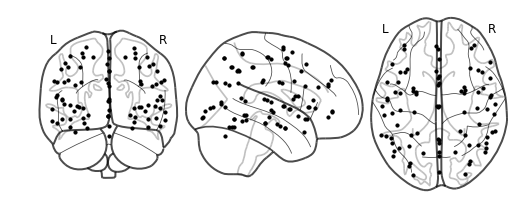

In [5]:
mask = nib.load(cluster_masks)
c = plot_cluster_centers(mask)

In [6]:
def package_data(masked_data, nii_files, regressor_files):
    nii_subjs = list(map(lambda f: f.split('/')[-1][:-len('.nii')], nii_files))
    reg_subjs = list(map(lambda f: f.split('/')[-1][:-len('_regs_results.mat')], regressor_files))
    
    data = []
    for i, s in enumerate(nii_subjs):
        try:
            j = np.ravel(np.where(np.array(list(map(lambda x: x == s, reg_subjs)))))[0]
            print(f'matching {s} with {regressor_files[j]}')
            regmat = load(regressor_files[j])
            data.append({'data': masked_data[i], 'regmat': regmat['all_regressors'], 'mvpa': regmat['results']})
        except:
            print(f'missing data for {s}')
    return data

In [7]:
data_fname = os.path.join('data', 'preprocessed.npz')
if os.path.exists(data_fname):
    print('loading preprocessed data from disk...')
    data = np.load(data_fname)['data']
else:
    print('preprocessed data...')
    masked_data = list(map(lambda f: apply_mask(nib.load(f), mask), nii_files))
    data = package_data(masked_data, nii_files, regressor_files)
    np.savez(os.path.join('data', 'preprocessed.npz'), data=data)

loading preprocessed data from disk...


In [21]:
regressors_key = ['Present list A', 
                  'Present list B (R)', 
                  'Present list B (F)',
                  'Recall list A (R)',
                  'Recall list B (R)', 
                  'Recall list A (F)',
                  'Recall list B (F)',
                  'Present localizer list 1',
                  'Recall localizer list 1',
                  'Present localizer list 2',
                  'Recall localizer list 2',
                  'Present scene localizer image',
                  'Present objects localizer image',
                  'Present scrambled scene localizer image']

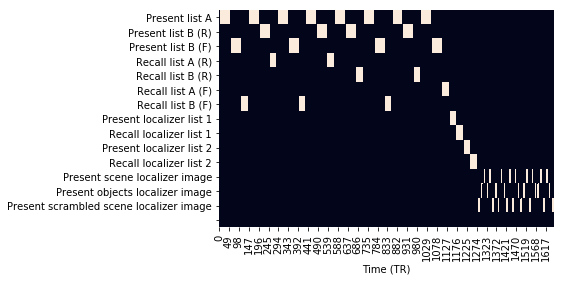

In [22]:
#experiment labels from participant 0
h = sns.heatmap(data[0]['regmat'], cbar=False)
h.set_yticklabels(regressors_key)
plt.yticks(rotation=0);
plt.xlabel('Time (TR)');

In [25]:
# credit: https://stackoverflow.com/questions/47004506/check-if-a-numpy-array-is-sorted
@numba.jit
def is_sorted(a):
    for i in range(a.size-1):
         if a[i+1] < a[i] :
               return False
    return True

In [31]:
def ribbon(x, y, lb, ub=None, color='k', alpha='0.5'):
    #assert is_sorted(x), 'x-coordinates must be monotonically increasing'
    
    if ub is None:
        ub = lb
    h1 = plt.fill_between(x, y-lb, y+ub, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color)
    return h1, h2